In [66]:
from pathlib import Path
import matplotlib.pyplot as plt
import time
from import_xy import parse_xy_file
%matplotlib widget


In [67]:
data_path = Path('data/NormalXPS.xy')
t_start = time.time()
xy = parse_xy_file(data_path)
t_end = time.time()
print(f"Data loaded in {t_end - t_start:.2f} seconds")

# print the names of the measurement groups and their corresponding metadata
for elem in xy.groups:
    print(elem.name)
    for e in elem.metadata.items():
        print(e)

Data loaded in 0.00 seconds
Cell vacuum 50C
('Scan Mode', 'FixedAnalyzerTransmission')
('Analyzer Lens Voltage', '1.5kV')
('Calibration File', 'C:/Users/Public/Documents/SpecsLab Prodigy/Database/DatasetCalib1D\\latest-fat.calib1d')
('Transmission File', 'C:\\Program Files\\SPECS\\SpecsLab Prodigy\\database\\TransmissionFunction/Default/Default.tf')
('Analyzer Slit', '3:1x20\\B:open')
('Iris Diameter', 60)
('Name', 'Monochromator')
('Polar Angle', '45 °')
('Azimuth Angle', '45 °')
('ex_energy', 49.99794762701864)
('device_state', 'operating')


In [68]:
# print the 'regions' in the file
xy.regions

[Region(id=2, name='Overview', group='Cell vacuum 50C', kind='single', n_scans=1),
 Region(id=5, name='Overview', group='Cell vacuum 50C', kind='single', n_scans=1),
 Region(id=6, name='O1s', group='Cell vacuum 50C', kind='single', n_scans=1),
 Region(id=7, name='Si2p_c', group='Cell vacuum 50C', kind='single', n_scans=1),
 Region(id=8, name='N1s', group='Cell vacuum 50C', kind='series', n_scans=3),
 Region(id=9, name='Si2p_c', group='Cell vacuum 50C', kind='single', n_scans=1),
 Region(id=10, name='C1s', group='Cell vacuum 50C', kind='series', n_scans=2),
 Region(id=11, name='Si2p_c', group='Cell vacuum 50C', kind='single', n_scans=1),
 Region(id=12, name='Si2p', group='Cell vacuum 50C', kind='single', n_scans=1),
 Region(id=13, name='Hf4f', group='Cell vacuum 50C', kind='series', n_scans=3),
 Region(id=14, name='VB', group='Cell vacuum 50C', kind='single', n_scans=1)]

In [69]:
# print the file metadata:
for elem in xy.file_metadata.items():
    print(elem)

('Created by', 'SpecsLab Prodigy, Version 4.137.2-r131684')
('XY-Serializer Export Settings', '')
('Comment Prefix', '#')
('Output Meta Data', 'yes')
('Energy Axis', 'Binding Energy')
('Count Rate', 'Counts per Second')
('Separate Scan Data', 'yes')
('Separate Channel Data', 'no')
('Separate Non-Energy Channels', 'yes')
('External Channel Data', 'no')
('Transmission Function', 'no')
('Error Bar', 'no')
('Operation Results', 'no')
('Time Zone Format', 'UTC')
('Experiment Description', '')


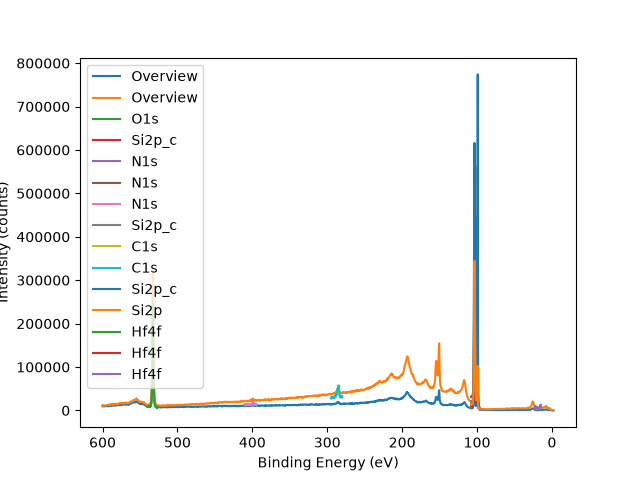

In [70]:
# plot all the XPS data as a function of binding energy

num_regions = len(xy.regions)
num_regions = num_regions if num_regions <= 10 else 10 # used to limit the amount of data if the file contains many scans

plt.close()
fig, ax = plt.subplots()
for r in xy.regions[:num_regions]:
    #print(r)
    for s in r.scans[:num_regions]:
        ax.xaxis.set_inverted(True)
        if len(s.intensity[:].shape) <= 1:
            ax.plot(s.energy[:], s.intensity[:], label=r.name)

ax.set_xlabel('Binding Energy (eV)')
ax.set_ylabel('Intensity (counts)')
ax.legend()